In [2]:
# ===============================
# Imports
# ===============================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
# ===============================
# Load Dataset
# ===============================

df = pd.read_csv("../data/raw/weather.csv")

print(df.shape)

df.head()

(151047, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


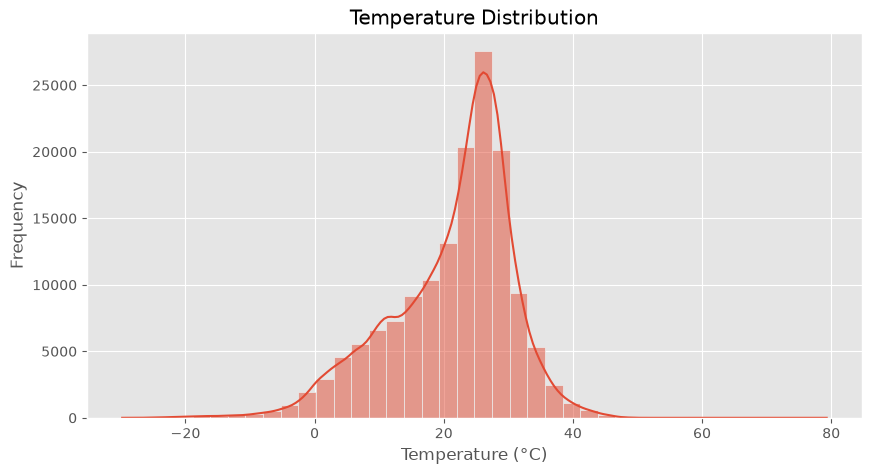

In [4]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="temperature_celsius",
    bins=40,
    kde=True
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

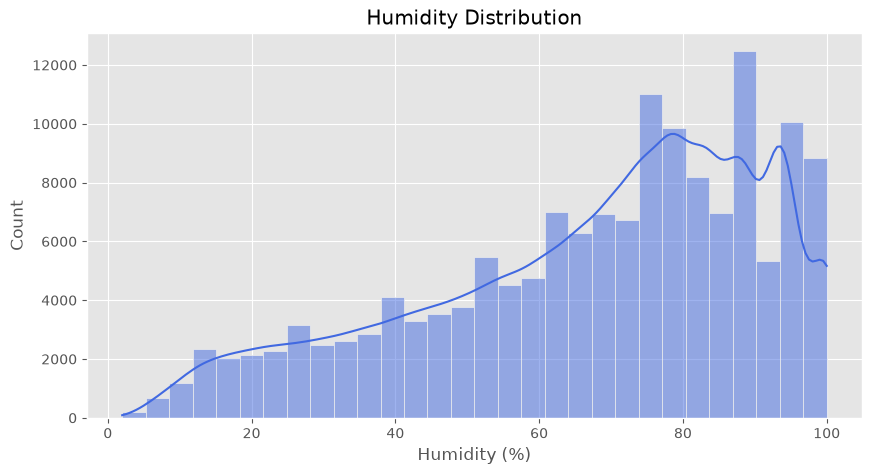

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["humidity"],
    bins=30,
    color="royalblue",
    kde=True
)

plt.title("Humidity Distribution")
plt.xlabel("Humidity (%)")

plt.show()

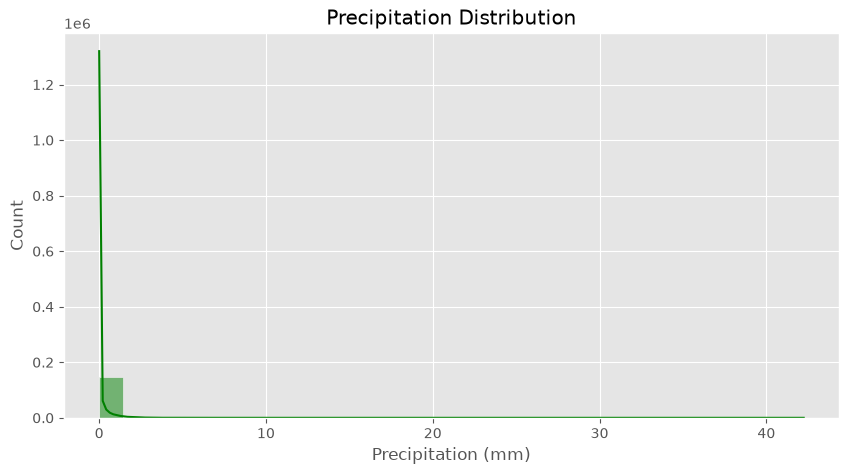

In [6]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["precip_mm"],
    bins=30,
    color="green",
    kde=True
)

plt.title("Precipitation Distribution")
plt.xlabel("Precipitation (mm)")

plt.show()

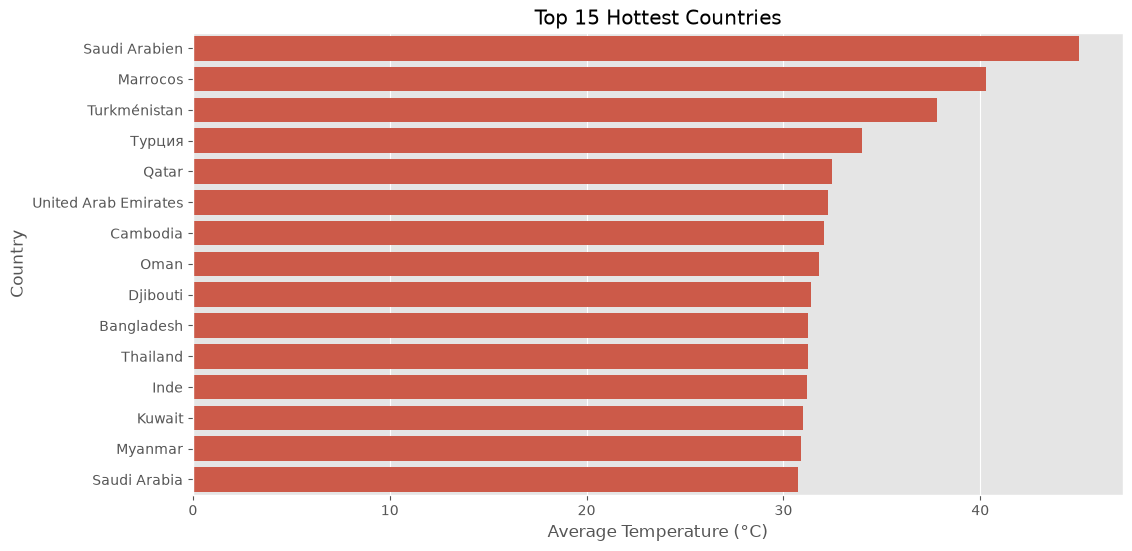

In [7]:
country_temp = (
    df.groupby("country")["temperature_celsius"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_temp.values,
    y=country_temp.index
)

plt.title("Top 15 Hottest Countries")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Country")

plt.show()

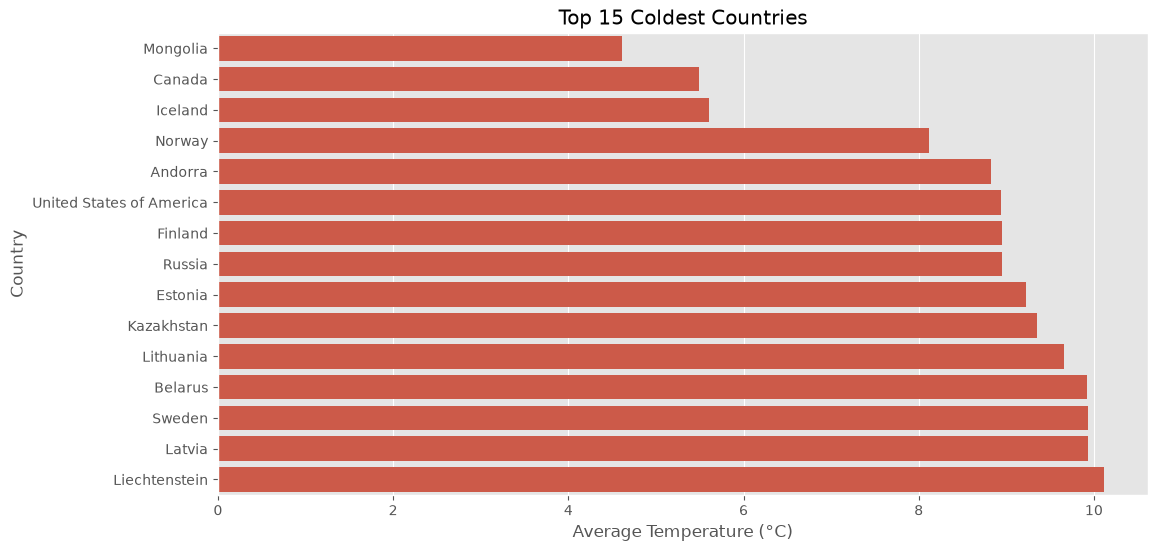

In [8]:
country_temp = (
    df.groupby("country")["temperature_celsius"]
      .mean()
      .sort_values()
      .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_temp.values,
    y=country_temp.index
)

plt.title("Top 15 Coldest Countries")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Country")

plt.show()

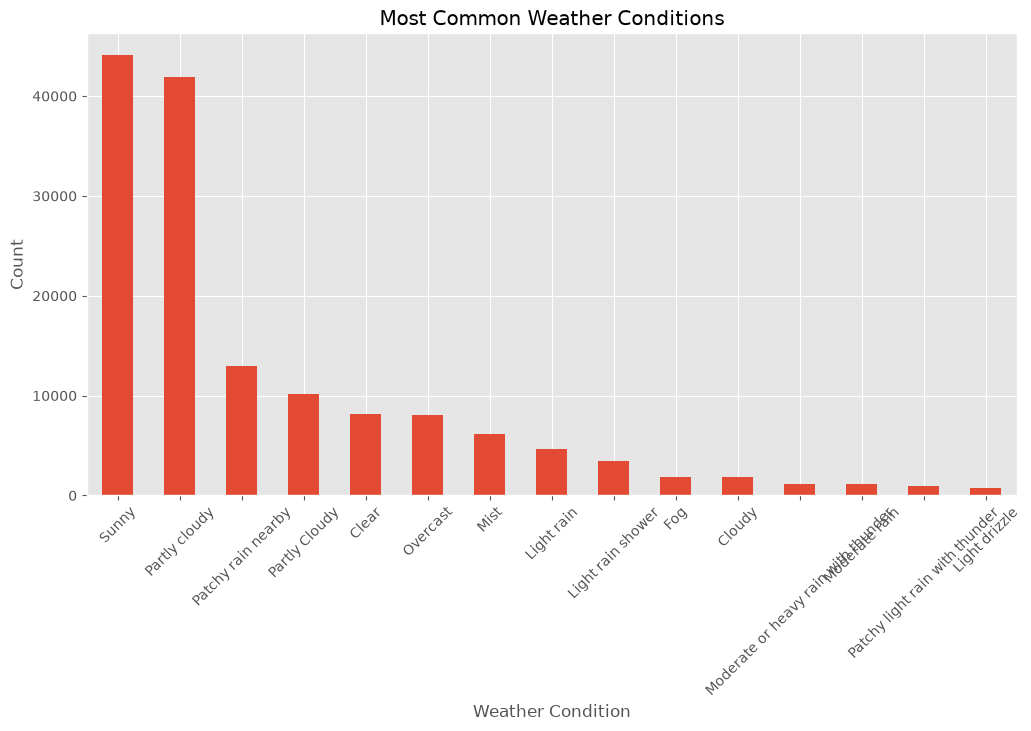

In [9]:
plt.figure(figsize=(12,6))

(
    df["condition_text"]
    .value_counts()
    .head(15)
    .plot(kind="bar")
)

plt.title("Most Common Weather Conditions")
plt.xlabel("Weather Condition")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

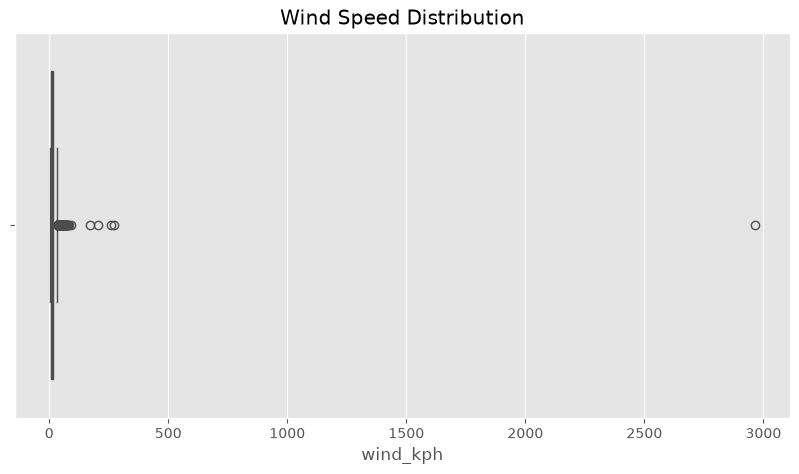

In [10]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["wind_kph"],
    color="orange"
)

plt.title("Wind Speed Distribution")

plt.show()

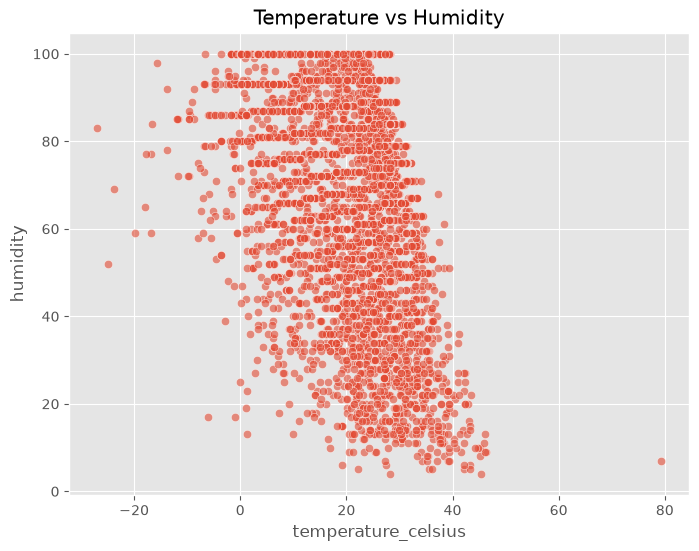

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x="temperature_celsius",
    y="humidity",
    alpha=0.6
)

plt.title("Temperature vs Humidity")

plt.show()

In [13]:
# Convert to datetime
df["last_updated"] = pd.to_datetime(df["last_updated"])

# Create new time features
df["year"] = df["last_updated"].dt.year
df["month"] = df["last_updated"].dt.month
df["day"] = df["last_updated"].dt.day
df["hour"] = df["last_updated"].dt.hour

# Check
df[["last_updated", "year", "month", "day", "hour"]].head()

,last_updated,year,month,day,hour
0,2024-05-16 13:15:00,2024,5,16,13
1,2024-05-16 10:45:00,2024,5,16,10
2,2024-05-16 09:45:00,2024,5,16,9
3,2024-05-16 10:45:00,2024,5,16,10
4,2024-05-16 09:45:00,2024,5,16,9


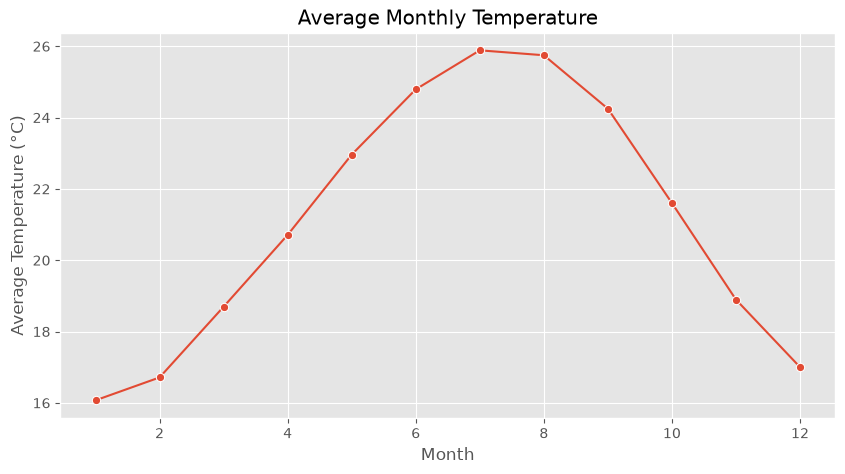

In [14]:
monthly = (
    df.groupby("month")["temperature_celsius"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly,
    x="month",
    y="temperature_celsius",
    marker="o"
)

plt.title("Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)

plt.show()

Implement anomaly detection and analyze outliers.

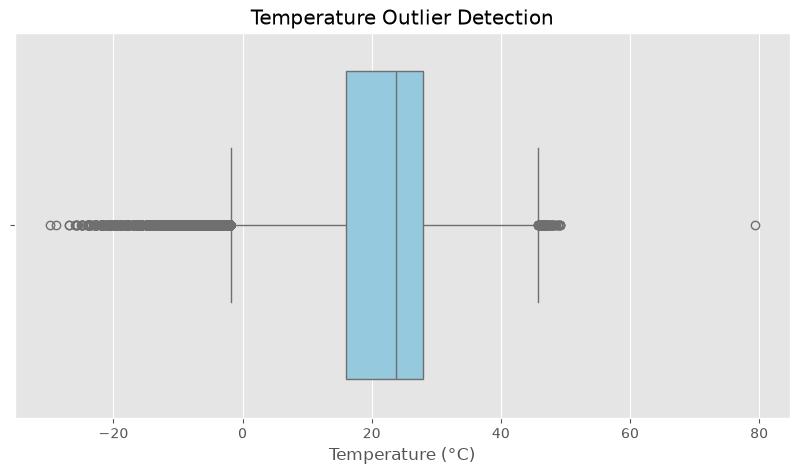

In [15]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["temperature_celsius"],
    color="skyblue"
)

plt.title("Temperature Outlier Detection")
plt.xlabel("Temperature (°C)")

plt.show()

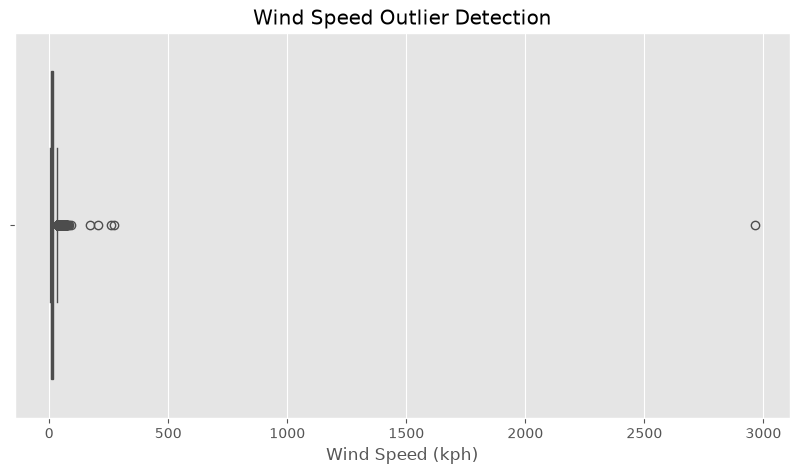

In [16]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["wind_kph"],
    color="orange"
)

plt.title("Wind Speed Outlier Detection")
plt.xlabel("Wind Speed (kph)")

plt.show()

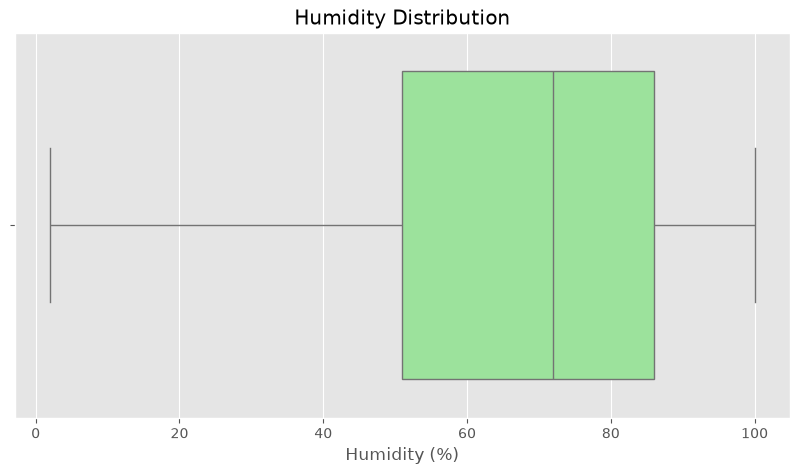

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["humidity"],
    color="lightgreen"
)

plt.title("Humidity Distribution")
plt.xlabel("Humidity (%)")

plt.show()

In [18]:
from sklearn.ensemble import IsolationForest

features = df[
    [
        "temperature_celsius",
        "humidity",
        "wind_kph",
        "pressure_mb",
        "precip_mm"
    ]
]

iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

df["anomaly"] = iso.fit_predict(features)

df["anomaly"].value_counts()

anomaly
 1    148026
-1      3021
Name: count, dtype: int64

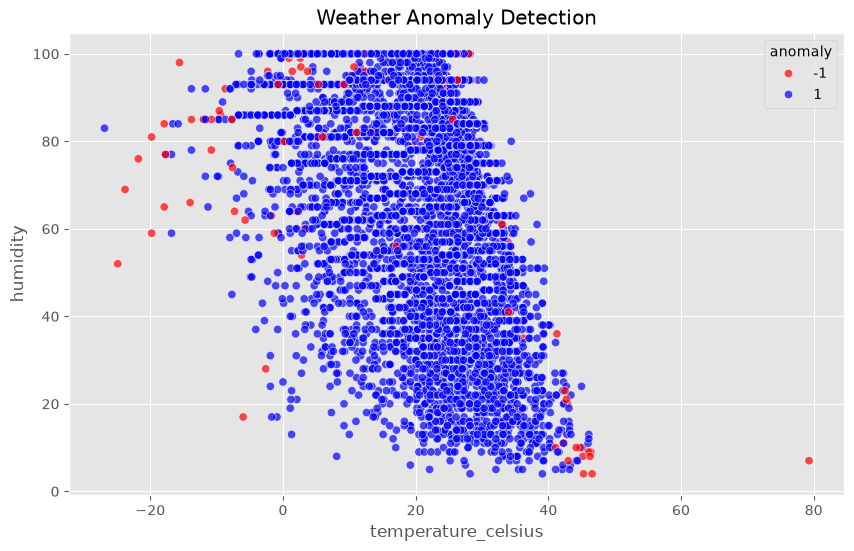

In [19]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(8000, random_state=42),
    x="temperature_celsius",
    y="humidity",
    hue="anomaly",
    palette={1: "blue", -1: "red"},
    alpha=0.7
)

plt.title("Weather Anomaly Detection")

plt.show()

In [20]:
df[df["anomaly"] == -1].head(20)

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,day,hour,anomaly
176,Tonga,Nuku`Aloia,-21.13,-175.20,Pacific/Tongatapu,1715849100,2024-05-16 21:45:00,23.0,73.4,Moderate rain,20.6,33.1,80,E,1016.0,29.99,2.09,0.08,100,100,25.2,77.3,6.0,3.0,1.0,35.3,56.8,217.0,36.8,0.1,0.1,2.4,6.3,1,1,07:04 AM,06:10 PM,01:47 PM,12:33 AM,Waxing Gibbous,55,2024,5,16,21,-1
181,Tuvalu,Funafuti,-8.52,179.22,Pacific/Funafuti,1715849100,2024-05-16 20:45:00,26.0,78.8,Moderate rain at times,12.5,20.2,90,E,1008.0,29.77,2.00,0.08,100,100,28.4,83.1,8.0,4.0,1.0,14.9,24.0,207.0,23.6,0.0,0.0,0.6,1.6,1,1,06:08 AM,05:51 PM,12:55 PM,12:13 AM,Waxing Gibbous,55,2024,5,16,20,-1
219,Brunei Darussalam,Bandar Seri Begawan,4.88,114.93,Asia/Brunei,1715868000,2024-05-16 22:00:00,27.0,80.6,Patchy light rain with thunder,6.9,11.2,150,SSE,1010.0,29.83,3.01,0.12,100,75,31.3,88.4,7.0,4.0,1.0,11.4,18.4,567.4,51.5,7.4,2.4,9.5,9.8,1,1,06:06 AM,06:27 PM,01:06 PM,12:54 AM,Waxing Gibbous,55,2024,5,16,22,-1
317,Netherlands,Amsterdam,52.37,4.89,Europe/Amsterdam,1715868000,2024-05-16 16:00:00,20.0,68.0,Partly cloudy,12.5,20.2,180,S,1003.0,29.62,2.42,0.10,68,50,20.0,68.0,10.0,6.0,4.0,17.0,27.4,263.7,29.0,32.9,3.2,12.1,13.0,1,2,05:43 AM,09:32 PM,01:39 PM,03:40 AM,Waxing Gibbous,55,2024,5,16,16,-1
371,Tonga,Nuku`Aloia,-21.13,-175.20,Pacific/Tongatapu,1715868900,2024-05-17 03:15:00,23.0,73.4,Light rain,11.9,19.1,130,SE,1017.0,30.03,2.29,0.09,94,100,25.3,77.5,8.0,4.0,1.0,35.9,57.8,217.0,38.6,0.0,0.1,2.2,6.4,1,1,07:04 AM,06:10 PM,01:47 PM,12:33 AM,Waxing Gibbous,55,2024,5,17,3,-1
490,Luxembourg,Luxembourg,49.61,6.13,Europe/Luxembourg,1715961600,2024-05-17 18:00:00,12.0,53.6,Heavy rain at times,16.1,25.9,280,W,1008.0,29.77,1.70,0.07,94,75,9.2,48.5,4.5,2.0,3.0,27.8,44.7,193.6,76.5,5.6,0.3,0.9,1.0,1,1,05:48 AM,09:17 PM,02:48 PM,03:41 AM,Waxing Gibbous,64,2024,5,17,18,-1
746,Sri Lanka,Colombo,6.93,79.85,Asia/Colombo,1716042600,2024-05-18 20:00:00,25.0,77.0,Light rain,5.6,9.0,150,SSE,1007.0,29.74,3.21,0.13,100,50,27.8,82.0,8.0,4.0,1.0,21.3,34.2,253.7,42.2,5.4,2.5,1.8,3.6,1,1,05:54 AM,06:20 PM,02:24 PM,02:06 AM,Waxing Gibbous,73,2024,5,18,20,-1
852,Iceland,Grindavik,63.83,-22.43,Atlantic/Reykjavik,1716128100,2024-05-19 14:15:00,4.0,39.2,Light rain,28.6,46.1,60,ENE,1007.0,29.74,1.00,0.04,87,100,-2.3,27.9,8.0,4.0,1.0,36.9,59.4,230.3,82.3,0.4,1.7,0.5,0.5,1,1,04:05 AM,10:50 PM,05:26 PM,03:48 AM,Waxing Gibbous,81,2024,5,19,14,-1
880,Maldives,Felidhoo,3.48,73.53,Indian/Maldives,1716128100,2024-05-19 19:15:00,28.8,83.9,Light rain shower,25.1,40.3,274,W,1008.0,29.76,1.02,0.04,80,100,34.2,93.5,10.0,6.0,1.0,36.8,59.3,213.6,32.9,0.0,0.1,1.9,5.3,1,1,05:54 AM,06:11 PM,03:01 PM,02:38 AM,Waxing Gibbous,81,2024,5,19,19,-1
935,Solomon Islands,Honiara,-9.43,159.95,Pacific/Guadalcanal,1716128100,2024-05-20 01:15:00,25.0,77.0,Partly cloudy,2.2,3.6,10,N,1008.0,29.77,13.05,0.51,94,75,28.4,83.0,10.0,6.0,1.0,3.7,6.0,217.0,24.7,0.6,0.3,0.5,0.6,1,1,06:27 AM,06:06 PM,03:02 PM,02:44 AM,Waxing Gibbous,81,2024,5,20,1,-1
